🔑 Introduce tu OPENAI_API_KEY: ··········
✅ API conectada
OK
(1536,)
      candidate  origin_cost  residual_norm  projected_norm
0      grounded     0.394518       0.628106        0.218332
2  hallucinated     0.795938       0.892154        0.330082
1       verbose     0.827010       0.909401        0.188700


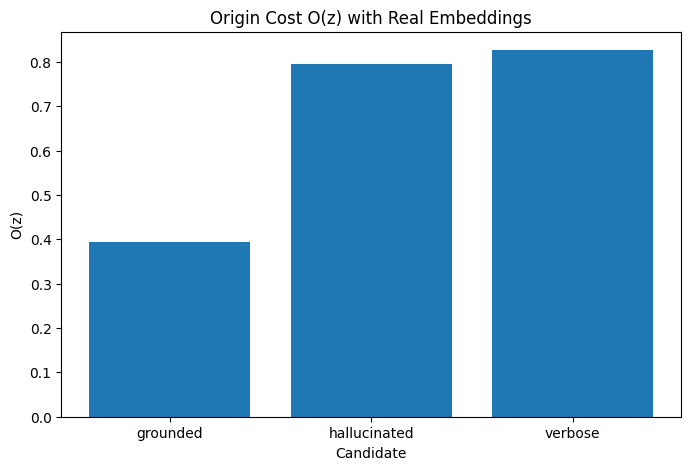

In [1]:
!pip install -q openai numpy matplotlib pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from getpass import getpass
from openai import OpenAI

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("🔑 Introduce tu OPENAI_API_KEY: ")

client = OpenAI()
print("✅ API conectada")

def get_embeddings(texts, model="text-embedding-3-small"):
    if isinstance(texts, str):
        texts = [texts]

    response = client.embeddings.create(
        model=model,
        input=texts
    )

    return [np.array(item.embedding, dtype=float) for item in response.data]

vec = get_embeddings("Semantic grounding matters for reliable LLM outputs.")[0]
print("OK")
print(vec.shape)

def build_reference_subspace(prompt_vec, axiom_vecs, knowledge_vecs, center=True, svd_tol=1e-10):
    all_vectors = [prompt_vec] + axiom_vecs + knowledge_vecs
    matrix = np.vstack(all_vectors)

    centroid = np.mean(matrix, axis=0) if center else None
    work_matrix = matrix - centroid if center else matrix.copy()

    _, s, vt = np.linalg.svd(work_matrix, full_matrices=False)
    rank = int(np.sum(s > svd_tol))
    basis = vt[:rank].T

    return {
        "basis": basis,
        "centroid": centroid,
        "rank": rank,
        "singular_values": s,
    }

def project_vector(vector, basis):
    return basis @ (basis.T @ vector)

def compute_origin_cost(candidate_vec, subspace):
    basis = subspace["basis"]
    centroid = subspace["centroid"]

    work_vec = candidate_vec - centroid if centroid is not None else candidate_vec.copy()
    projected = project_vector(work_vec, basis)
    residual = work_vec - projected

    residual_norm = float(np.linalg.norm(residual))
    projected_norm = float(np.linalg.norm(projected))
    origin_cost = float(residual_norm ** 2)

    return {
        "origin_cost": origin_cost,
        "residual_norm": residual_norm,
        "projected_norm": projected_norm,
    }

prompt = "Explain why semantic grounding matters for reliable LLM outputs."

axioms = [
    "A response should remain structurally aligned with its originating context.",
    "Semantic drift increases hallucination risk.",
]

knowledge = [
    "Grounded responses tend to preserve relevance and coherence.",
    "Ungrounded responses often become verbose, speculative, or inconsistent.",
]

candidates = {
    "grounded": "Semantic grounding matters because it keeps the response tied to the original context and reduces drift.",
    "verbose": "Language models operate in many dimensions of possibility, and meaning can unfold through many interpretive layers beyond immediate context.",
    "hallucinated": "Semantic grounding matters mainly because it improves hardware memory allocation in transformer GPUs."
}

prompt_vec = get_embeddings(prompt)[0]
axiom_vecs = get_embeddings(axioms)
knowledge_vecs = get_embeddings(knowledge)
candidate_vecs = {name: get_embeddings(text)[0] for name, text in candidates.items()}

subspace = build_reference_subspace(prompt_vec, axiom_vecs, knowledge_vecs)

results = {}
for name, vec in candidate_vecs.items():
    results[name] = compute_origin_cost(vec, subspace)

rows = []
for name, r in results.items():
    rows.append({
        "candidate": name,
        "origin_cost": r["origin_cost"],
        "residual_norm": r["residual_norm"],
        "projected_norm": r["projected_norm"],
    })

df = pd.DataFrame(rows).sort_values("origin_cost")
print(df)

plt.figure(figsize=(8, 5))
plt.bar(df["candidate"], df["origin_cost"])
plt.title("Origin Cost O(z) with Real Embeddings")
plt.ylabel("O(z)")
plt.xlabel("Candidate")
plt.show()